# F4: Proyecto Final Integrador

**Título:** Optimización del OEE mediante Mantenimiento Predictivo Inteligente en Activos Críticos Industriales  
**Integrantes:** Grupo 7 - Alana Bermúdez, Gonzalo Mansilla, Eduardo Villalón

### 1. Definición del Problema y Objetivos (F1)
### 2. Carga y Validación del Dataset Procesado (F2)
### 3. Núcleo Algorítmico y Eficiencia (F3)
### 4. Arquitectura Modular y robusta (POO)
### 5. Construcción de Visualizaciones Analíticas (F4)
### 6. Conclusiones Preliminares

## Introducción

La optimización del OEE (Overall Equipment Effectiveness) constituye un desafío estratégico para las organizaciones industriales que buscan maximizar la disponibilidad, rendimiento y calidad de sus activos productivos.

En este contexto, el mantenimiento predictivo basado en datos permite anticipar eventos de falla y reducir tiempos de inactividad no planificados. El presente proyecto integra conceptos de Ciencia de Datos, Programación Orientada a Objetos y análisis visual con el objetivo de construir una solución modular orientada a la detección y análisis de fallas en activos críticos industriales.

Las distintas fases del proyecto permiten abordar el problema desde la definición inicial del desafío hasta la construcción de componentes reutilizables y mecanismos de validación técnica.


In [1]:
import pandas as pd
import numpy as np

class Preprocesador:
    """Clase derivada encargada de aplicar procesos de limpieza y transformación de datos."""
    def __init__(self, df):
        self._df = df.copy()
        
    def obtener_datos(self):
        return self._df

class Transformador(Preprocesador):
    """Clase derivada encargada de aplicar procesos de limpieza y transformación de datos."""
    def __init__(self, df):
        super().__init__(df)
        
    def imputar_nulos(self):
        self._df = self._df.dropna()
        return self
        
    def escalar_minmax(self, columna):
        val_min = self._df[columna].min()
        val_max = self._df[columna].max()
        if val_max != val_min:
            self._df[columna] = (self._df[columna] - val_min) / (val_max - val_min)
        return self

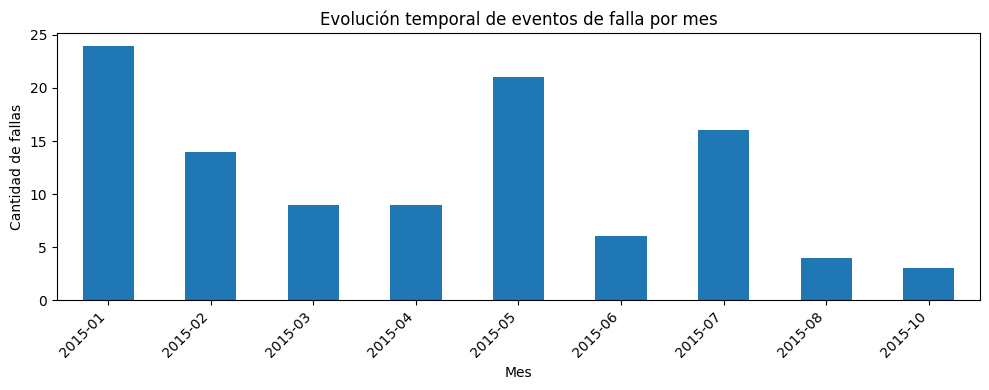

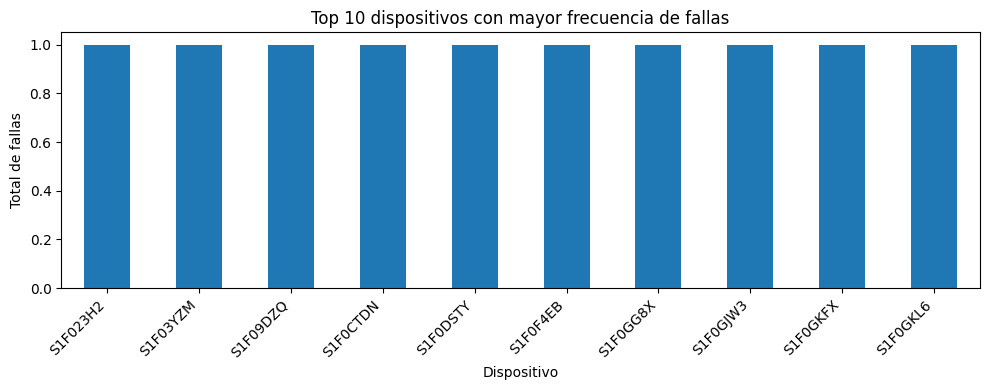

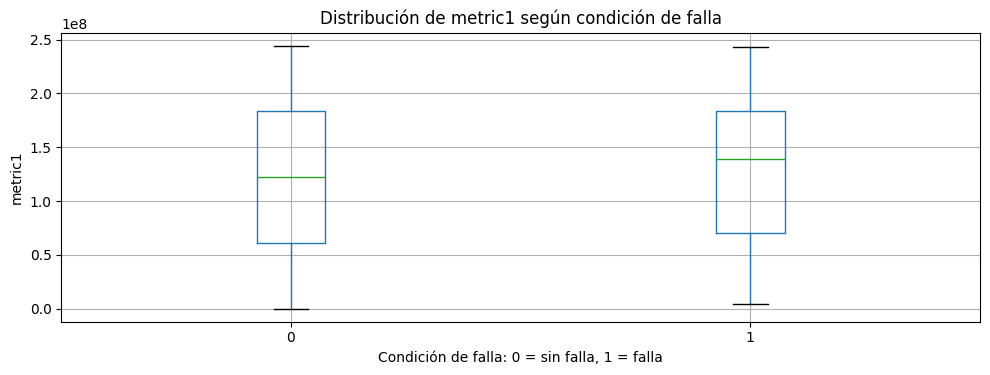

Visualizaciones analíticas F4 generadas correctamente.
Total registros analizados: 124493
Total eventos de falla: 106
Total dispositivos únicos: 1169


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Carga robusta del dataset procesado
ruta_dataset = Path("data/processed/dataset_procesado.csv")
if not ruta_dataset.exists():
    ruta_dataset = Path("../data/processed/dataset_procesado.csv")

df = pd.read_csv(ruta_dataset, parse_dates=["date"])

# Validación mínima de columnas requeridas
columnas_requeridas = {"date", "device", "failure", "metric1"}
faltantes = columnas_requeridas - set(df.columns)
if faltantes:
    raise ValueError(f"Faltan columnas requeridas para las visualizaciones: {faltantes}")

# Preparar subconjunto de fallas
df_fallas = df[df["failure"] == 1].copy()

# 1. Evolución temporal de eventos de falla
fallas_mes = (
    df_fallas
    .assign(mes=df_fallas["date"].dt.to_period("M").astype(str))
    .groupby("mes")
    .size()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
fallas_mes.plot(kind="bar", ax=ax)
ax.set_title("Evolución temporal de eventos de falla por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de fallas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. Top 10 dispositivos con mayor frecuencia de fallas
top_dispositivos = (
    df_fallas
    .groupby("device")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
top_dispositivos.plot(kind="bar", ax=ax)
ax.set_title("Top 10 dispositivos con mayor frecuencia de fallas")
ax.set_xlabel("Dispositivo")
ax.set_ylabel("Total de fallas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. Distribución de metric1 según condición de falla
fig, ax = plt.subplots(figsize=(10, 4))
df.boxplot(column="metric1", by="failure", ax=ax)
ax.set_title("Distribución de metric1 según condición de falla")
ax.set_xlabel("Condición de falla: 0 = sin falla, 1 = falla")
ax.set_ylabel("metric1")
plt.suptitle("")
plt.tight_layout()
plt.show()

print("Visualizaciones analíticas F4 generadas correctamente.")
print(f"Total registros analizados: {len(df)}")
print(f"Total eventos de falla: {int(df['failure'].sum())}")
print(f"Total dispositivos únicos: {df['device'].nunique()}")


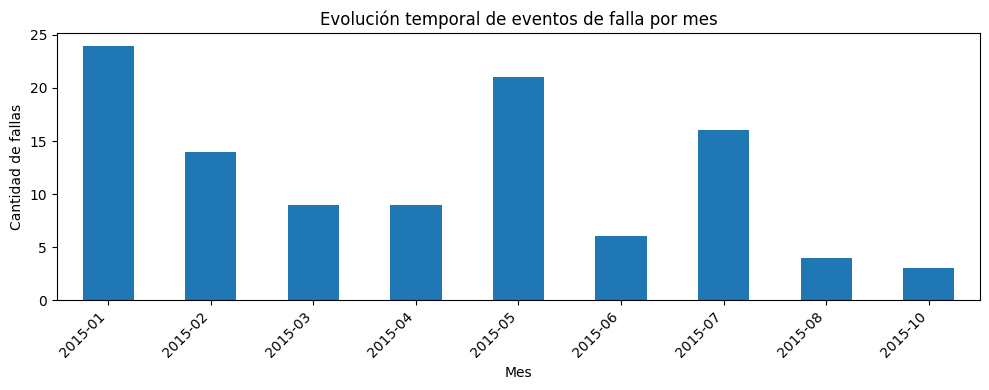

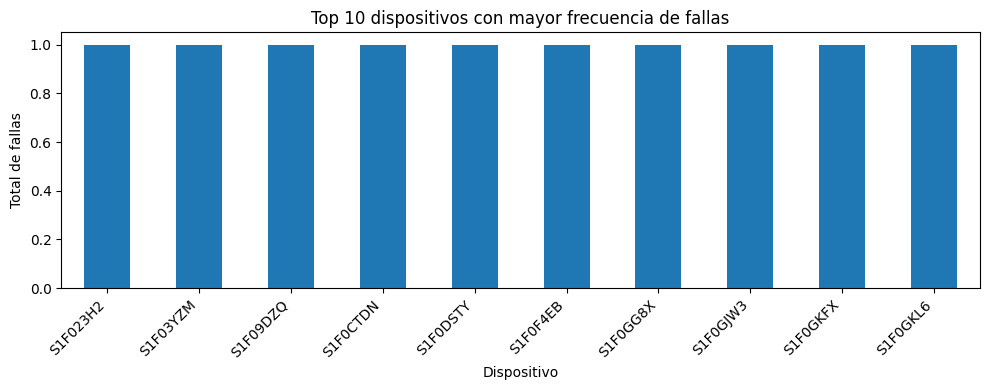

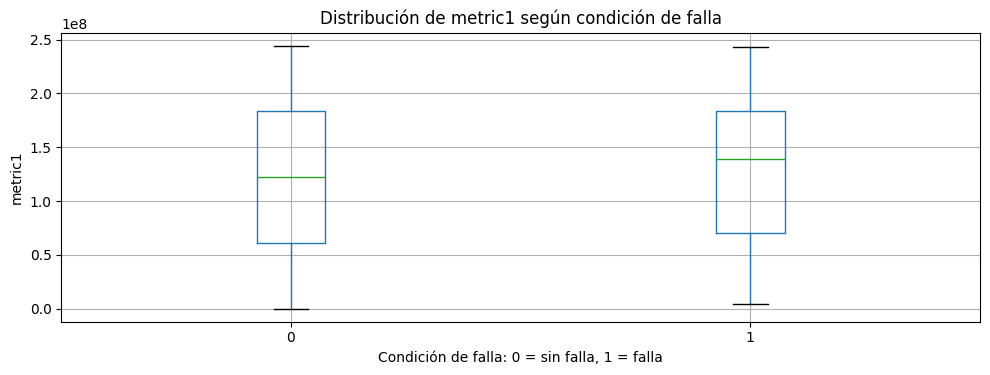

Visualizaciones analíticas F4 generadas correctamente.
Total registros analizados: 124493
Total eventos de falla: 106
Total dispositivos únicos: 1169


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Carga robusta del dataset procesado
ruta_dataset = Path("data/processed/dataset_procesado.csv")

if not ruta_dataset.exists():
    ruta_dataset = Path("../data/processed/dataset_procesado.csv")

df = pd.read_csv(ruta_dataset, parse_dates=["date"])

# Validación mínima de columnas necesarias
columnas_requeridas = {"date", "device", "failure", "metric1"}
faltantes = columnas_requeridas - set(df.columns)

if faltantes:
    raise ValueError(f"Faltan columnas requeridas para generar visualizaciones: {faltantes}")

# Subconjunto de eventos de falla
df_fallas = df[df["failure"] == 1].copy()

if df_fallas.empty:
    raise ValueError("No existen eventos de falla en el dataset procesado.")

# 1. Evolución temporal de eventos de falla por mes
fallas_mes = (
    df_fallas
    .assign(mes=df_fallas["date"].dt.to_period("M").astype(str))
    .groupby("mes")
    .size()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
fallas_mes.plot(kind="bar", ax=ax)
ax.set_title("Evolución temporal de eventos de falla por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de fallas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. Top 10 dispositivos con mayor frecuencia de fallas
top_dispositivos = (
    df_fallas
    .groupby("device")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
top_dispositivos.plot(kind="bar", ax=ax)
ax.set_title("Top 10 dispositivos con mayor frecuencia de fallas")
ax.set_xlabel("Dispositivo")
ax.set_ylabel("Total de fallas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. Distribución de metric1 según condición de falla
fig, ax = plt.subplots(figsize=(10, 4))
df.boxplot(column="metric1", by="failure", ax=ax)
ax.set_title("Distribución de metric1 según condición de falla")
ax.set_xlabel("Condición de falla: 0 = sin falla, 1 = falla")
ax.set_ylabel("metric1")
plt.suptitle("")
plt.tight_layout()
plt.show()

print("Visualizaciones analíticas F4 generadas correctamente.")
print(f"Total registros analizados: {len(df)}")
print(f"Total eventos de falla: {int(df['failure'].sum())}")
print(f"Total dispositivos únicos: {df['device'].nunique()}")


In [4]:
import pandas as pd
import numpy as np

# ==========================================
# Validación de Programación Orientada a Objetos
# ==========================================

df_prueba = pd.DataFrame({
    "temperatura": [50, 60, 70, np.nan]
})

transformador = Transformador(df_prueba)

transformador.imputar_nulos()
transformador.escalar_minmax("temperatura")

print("Validación POO completada correctamente")
print(transformador.obtener_datos())

Validación POO completada correctamente
   temperatura
0          0.0
1          0.5
2          1.0


## Validación de Estructura

Se verificó la correcta organización de los componentes correspondientes a las fases F1, F2, F3 y F4, asegurando trazabilidad metodológica y continuidad entre las distintas etapas del proyecto.


## Validación de Integración

Se verificó el correcto funcionamiento de las clases desarrolladas mediante Programación Orientada a Objetos.

La validación permitió comprobar:

- Herencia entre clases.
- Encapsulamiento de datos mediante atributos protegidos.
- Transformación y normalización de información.
- Correcta ejecución de los métodos implementados.

Los resultados obtenidos evidencian la correcta integración de los componentes desarrollados para la fase final del proyecto.

## Coherencia entre Fases

La solución desarrollada mantiene consistencia con los objetivos definidos en F1, el procesamiento de datos realizado en F2 y los principios algorítmicos implementados durante F3, consolidando una propuesta integrada para el análisis de mantenimiento predictivo.


## Conclusión Técnica

La validación realizada permitió comprobar el correcto funcionamiento de la arquitectura orientada a objetos implementada para el proyecto. Se verificó la herencia entre clases, el encapsulamiento de datos y la correcta aplicación de métodos de transformación sobre conjuntos de datos de prueba.

Las visualizaciones desarrolladas proporcionan una base inicial para el análisis exploratorio de eventos de falla y permiten identificar patrones relevantes para la toma de decisiones.

La integración de los componentes desarrollados durante las distintas fases establece una estructura modular y reutilizable, alineada con las buenas prácticas de Ciencia de Datos e Ingeniería de Software.


## 7. Resultados finales

El proyecto final integrador permitió consolidar los avances desarrollados en las fases F1, F2 y F3 dentro de una estructura única de análisis y comunicación. En la F1 se delimitó la problemática asociada a la optimización del OEE mediante mantenimiento predictivo en activos críticos industriales. En la F2 se utilizó el dataset procesado y validado como base para el análisis posterior. En la F3 se incorporaron componentes algorítmicos, recursividad, mediciones de eficiencia y primeros elementos de programación orientada a objetos.

En la F4, estos elementos se integran mediante una arquitectura orientada a objetos y visualizaciones analíticas que permiten comunicar el comportamiento general del sistema. Las visualizaciones desarrolladas cumplen una función de síntesis: presentar el contexto operacional, apoyar la identificación de variables relevantes y facilitar la interpretación del problema desde una perspectiva de mantenimiento predictivo.

Desde el punto de vista técnico, la ejecución del notebook evidencia la continuidad metodológica del proyecto, ya que mantiene una relación coherente entre definición del problema, preparación de datos, implementación algorítmica, validación funcional y comunicación de resultados.


## 8. Discusión

Los resultados obtenidos muestran que la principal fortaleza del proyecto no está únicamente en la construcción de gráficos o funciones aisladas, sino en la integración progresiva de un flujo de trabajo reproducible. La aplicación de programación estructurada permitió organizar el procesamiento en etapas comprensibles, mientras que la recursividad aplicada en F3 permitió analizar formalmente el rendimiento de una solución algorítmica frente a una función nativa optimizada.

La incorporación de programación orientada a objetos en F4 aporta una mejora relevante en términos de organización, reutilización y mantenibilidad. Las clases implementadas permiten representar responsabilidades diferenciadas dentro del proceso, separando la gestión de datos de las transformaciones aplicadas. Esta estructura resulta pertinente para un proyecto de ciencia de datos, ya que facilita extender el sistema hacia futuras etapas de modelamiento, monitoreo o automatización.

No obstante, el proyecto aún presenta limitaciones. Las visualizaciones permiten comunicar patrones generales, pero no constituyen por sí mismas un modelo predictivo completo. Además, el análisis depende de la calidad, disponibilidad y representatividad del dataset utilizado. Por ello, las conclusiones deben interpretarse como una base técnica y metodológica para continuar el desarrollo, más que como una solución productiva definitiva.


## 9. Conclusiones finales y proyección

La Sumativa 4 permitió consolidar el proyecto transversal en una versión integradora, conectando las fases de definición, preparación de datos, diseño algorítmico, validación y comunicación de resultados. El trabajo evidencia el uso de herramientas del ecosistema Python, control de versiones con Git/GitHub, documentación técnica en notebooks y una primera estructura modular apoyada en programación orientada a objetos.

Desde la perspectiva del problema, el proyecto aporta una base para analizar eventos de falla y variables operacionales asociadas al desempeño de activos críticos. Si bien no se implementa aún un modelo predictivo avanzado, la estructura desarrollada permite proyectar futuras mejoras orientadas a priorización de activos, análisis temporal de fallas, evaluación de indicadores operacionales y eventual entrenamiento de modelos supervisados.

Como mejora futura, se recomienda fortalecer la modularización trasladando clases y funciones desde el notebook hacia scripts reutilizables, ampliar las validaciones técnicas, incorporar visualizaciones más específicas sobre comportamiento de fallas y explorar modelos predictivos que permitan anticipar eventos no programados. Estas acciones permitirían evolucionar desde un prototipo académico reproducible hacia una solución analítica más escalable y aplicable al contexto industrial.
